In [11]:
using LinearAlgebra
using Distributed

println("hostname = ", readchomp(`hostname`))
println("threads = ", Threads.nthreads())
println("workers = ", nworkers())
println("BLAS threads = ", BLAS.get_num_threads())

hostname = wifi-secure1-897.sri.ucl.ac.be
threads = 1
workers = 1
BLAS threads = 4


In [1]:
using Eliashberg
using CairoMakie

[ Info: Precompiling Eliashberg [adbadfb0-2f75-4cd8-9a77-6e8457d2b59b] (cache misses: include_dependency fsize change (2), mismatched flags (16))

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up
ERROR: Method overwriting is not permitted during Module precompilation. Use `__precompile__(false)` to opt-out of precompilation.
┌ Info: Skipping precompilation due to precompilable error. Importing Eliashberg [adbadfb0-2f75-4cd8-9a77-6e8457d2b59b].
└   exception = Error when precompiling module, potentially caused by a __precompile__(false) declaration in the module.


┌ Info: Parse Quantum ESPRESSO bands with XML metadata started
│   • dir        : ./
│   • prefix     : Si
│   • bands_file : Si.band.dat
│   stage = "Parse Quantum ESPRESSO bands with XML metadata"
│   status = :start
└   context = (dir = "./", prefix = "Si", bands_file = "Si.band.dat")
┌ Info: Parse Quantum ESPRESSO bands with XML metadata finished
│   stage = "Parse Quantum ESPRESSO bands with XML metadata"
│   status = :finish
│   elapsed_s = 3.363899833
│   context = (dir = "./", prefix = "Si", bands_file = "Si.band.dat")
└   summary = nothing
┌ Info: Parse Wannier90 bands with XML metadata started
│   • dir      : ./
│   • prefix   : Si
│   • seedname : silicon
│   stage = "Parse Wannier90 bands with XML metadata"
│   status = :start
└   context = (dir = "./", prefix = "Si", seedname = "silicon")
┌ Info: Parse Wannier90 labelinfo started
│   • filename : ./silicon_band.labelinfo.dat
│   stage = "Parse Wannier90 labelinfo"
│   status = :start
└   context = (filename = "./silicon_b

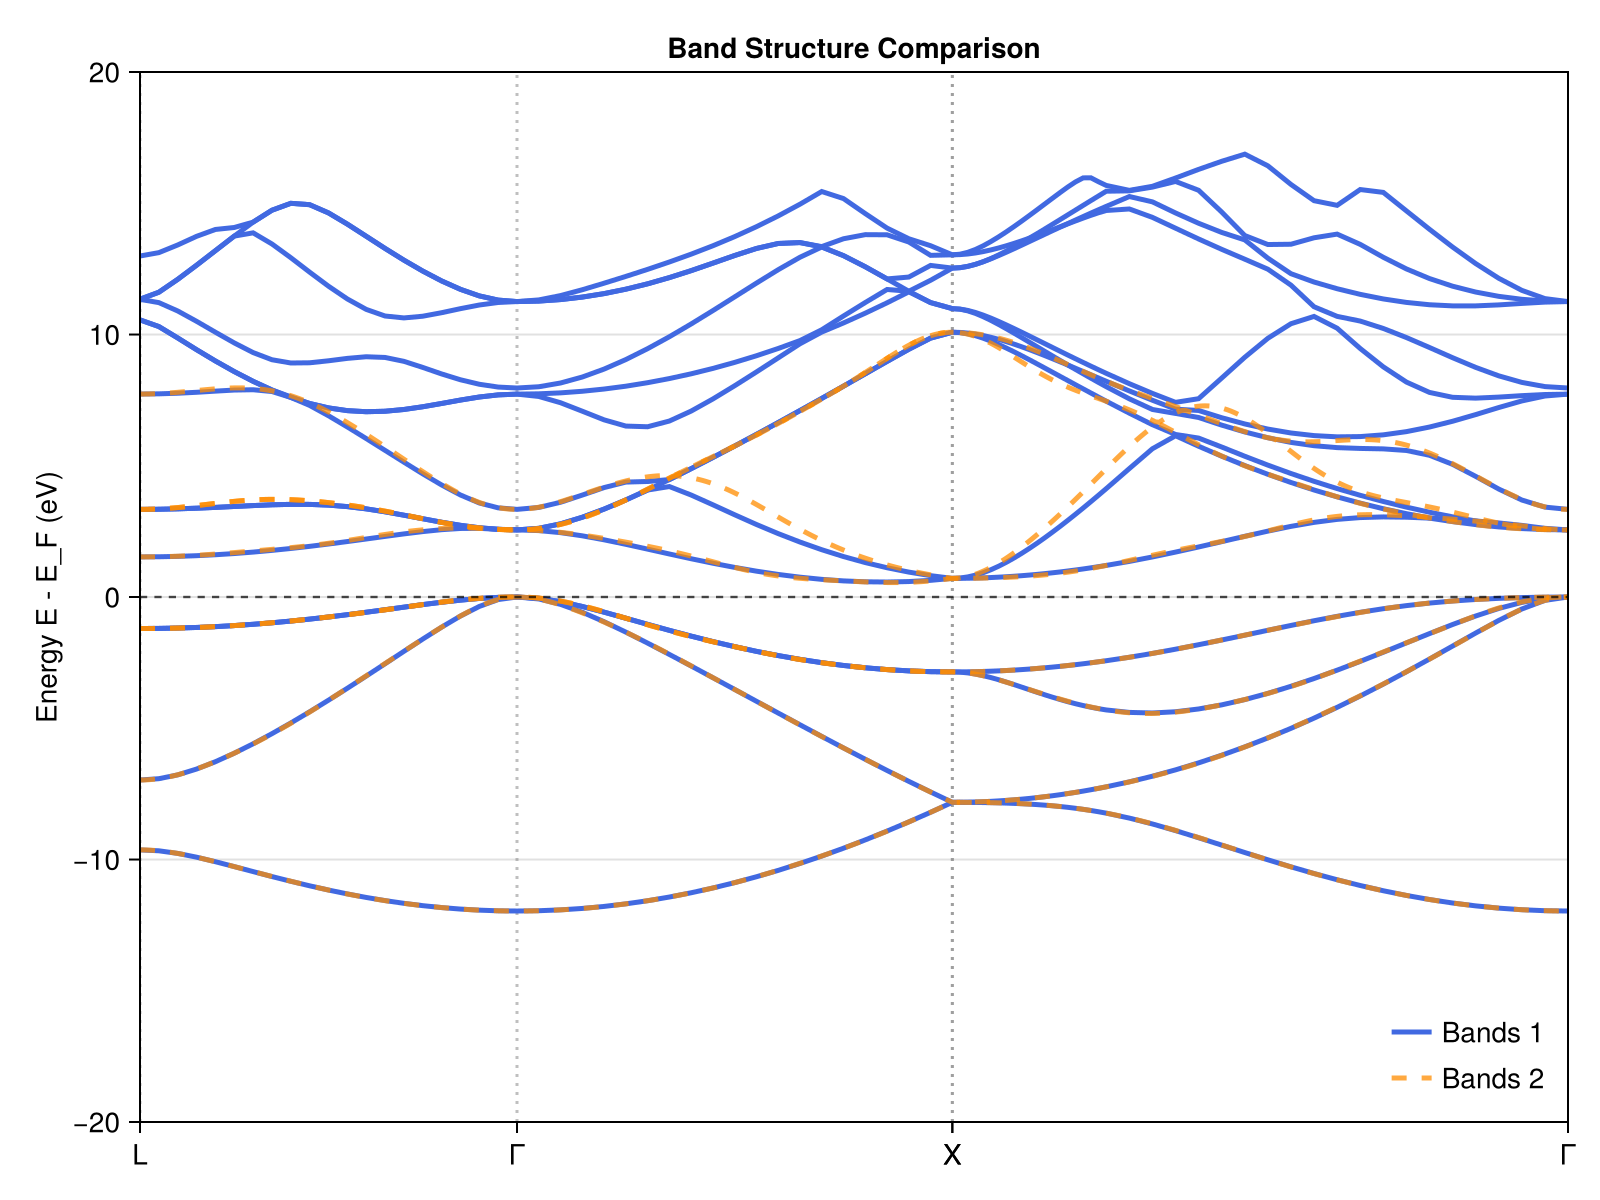

In [2]:
qe_bands = parse_quantum_espresso_bands("./", "Si")
w90_bands = parse_wannier90_band_dat("./", "Si", "silicon")

plot(qe_bands, w90_bands, ylims=[-20, 20])

## 2D Tight-Binding model 

In [ ]:
tb_wannier90 = parse_wannier90_tb("silicon_tb.dat")

kpoints = generate_kgrid(tb_wannier90.cell, 50, 50)

model = TightBinding(tb_wannier90, 1.0, -0.3)

path = generate_kpath(structure, n_pts_per_segment=200)

┌ Info: Parse Wannier90 TB started
│   • filename    : silicon_tb.dat
│   • periodicity : nothing
│   stage = "Parse Wannier90 TB"
│   status = :start
└   context = (filename = "silicon_tb.dat", periodicity = nothing)


))

┌ Info: Parse Wannier90 TB finished
│   • cell                : PeriodicCell(TTT, [-2.715500098505827, 0.0, 2.715500098505827]Å, [0.0, 2.715500098505827, 2.715500098505827]Å, [-2.715500098505827, 2.715500098505827, 0.0]Å
│   • num_wann            : 8
│   • n_hoppings          : 39464
│   • n_position_matrices : 39344
│   stage = "Parse Wannier90 TB"
│   status = :finish
│   elapsed_s = 0.098558083
│   context = (filename = "silicon_tb.dat", periodicity = nothing)
└   summary = (cell = PeriodicCell(TTT, [-2.715500098505827, 0.0, 2.715500098505827]Å, [0.0, 2.715500098505827, 2.715500098505827]Å, [-2.715500098505827, 2.715500098505827, 0.0]Å, num_wann = 8, n_hoppings = 39464, n_position_matrices = 39344)


LoadError: UndefVarError: `structure` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [7]:
# 加载并解析 TOML
config_path = "./plasmon_2d.toml"
config = load_config(config_path)
# 打印配置以确保解析正确
display(config)

EliashbergConfig(Eliashberg.Config.SystemOptions(31, true, nothing, true, "examples/plasmon/results", "plasmon_2d", "plasmon_scan", true, true, true, "runner.log", "info", false), Eliashberg.Config.PredefinedStructureOption("square_lattice", 1.5, nothing, "C", nothing), Eliashberg.Config.KpointsOptions([50, 50]), Eliashberg.Config.TightBindingOption(-0.5, Eliashberg.Config.HoppingDef[], -1.0, 0.2, false), Eliashberg.Config.BareCoulombInteractionOption(0.01), Eliashberg.Config.DirectChannelOption(), Eliashberg.Config.SpectralFunctionOption(nothing, nothing, 100, [0.0, 5.0], 400, 0.01, 0.02), Eliashberg.Config.PlotOptions(false, "output/rpa_scan_result", nothing, "viridis", 300))

┌ Info: Calculate bands (KPath) started
│   • model : TightBinding (2D, 2 hoppings, EF=-0.3)
│   • kpath : KPath (2D, 601 points)
│   stage = "Calculate bands (KPath)"
│   status = :start
└   context = (model = TightBinding (2D, 2 hoppings, EF=-0.3), kpath = KPath (2D, 601 points))
┌ Info: Calculate bands (KPath) finished
│   • summary     : BandStructureData(1 bands, 601 k-points)
│   stage = "Calculate bands (KPath)"
│   status = :finish
│   elapsed_s = 0.3161615
│   context = (model = TightBinding (2D, 2 hoppings, EF=-0.3), kpath = KPath (2D, 601 points))
└   summary = BandStructureData(1 bands, 601 k-points)
┌ Info: Plot band structure started
│   • kpath   : KPath (2D, 601 points)
│   • n_bands : 1
│   • E_Fermi : 0.0
│   stage = "Plot band structure"
│   status = :start
└   context = (kpath = KPath (2D, 601 points), n_bands = 1, E_Fermi = 0.0)
┌ Info: Plot band structure finished
│   • figure_type : Figure
│   stage = "Plot band structure"
│   status = :finish
│   elapsed_s = 4.5

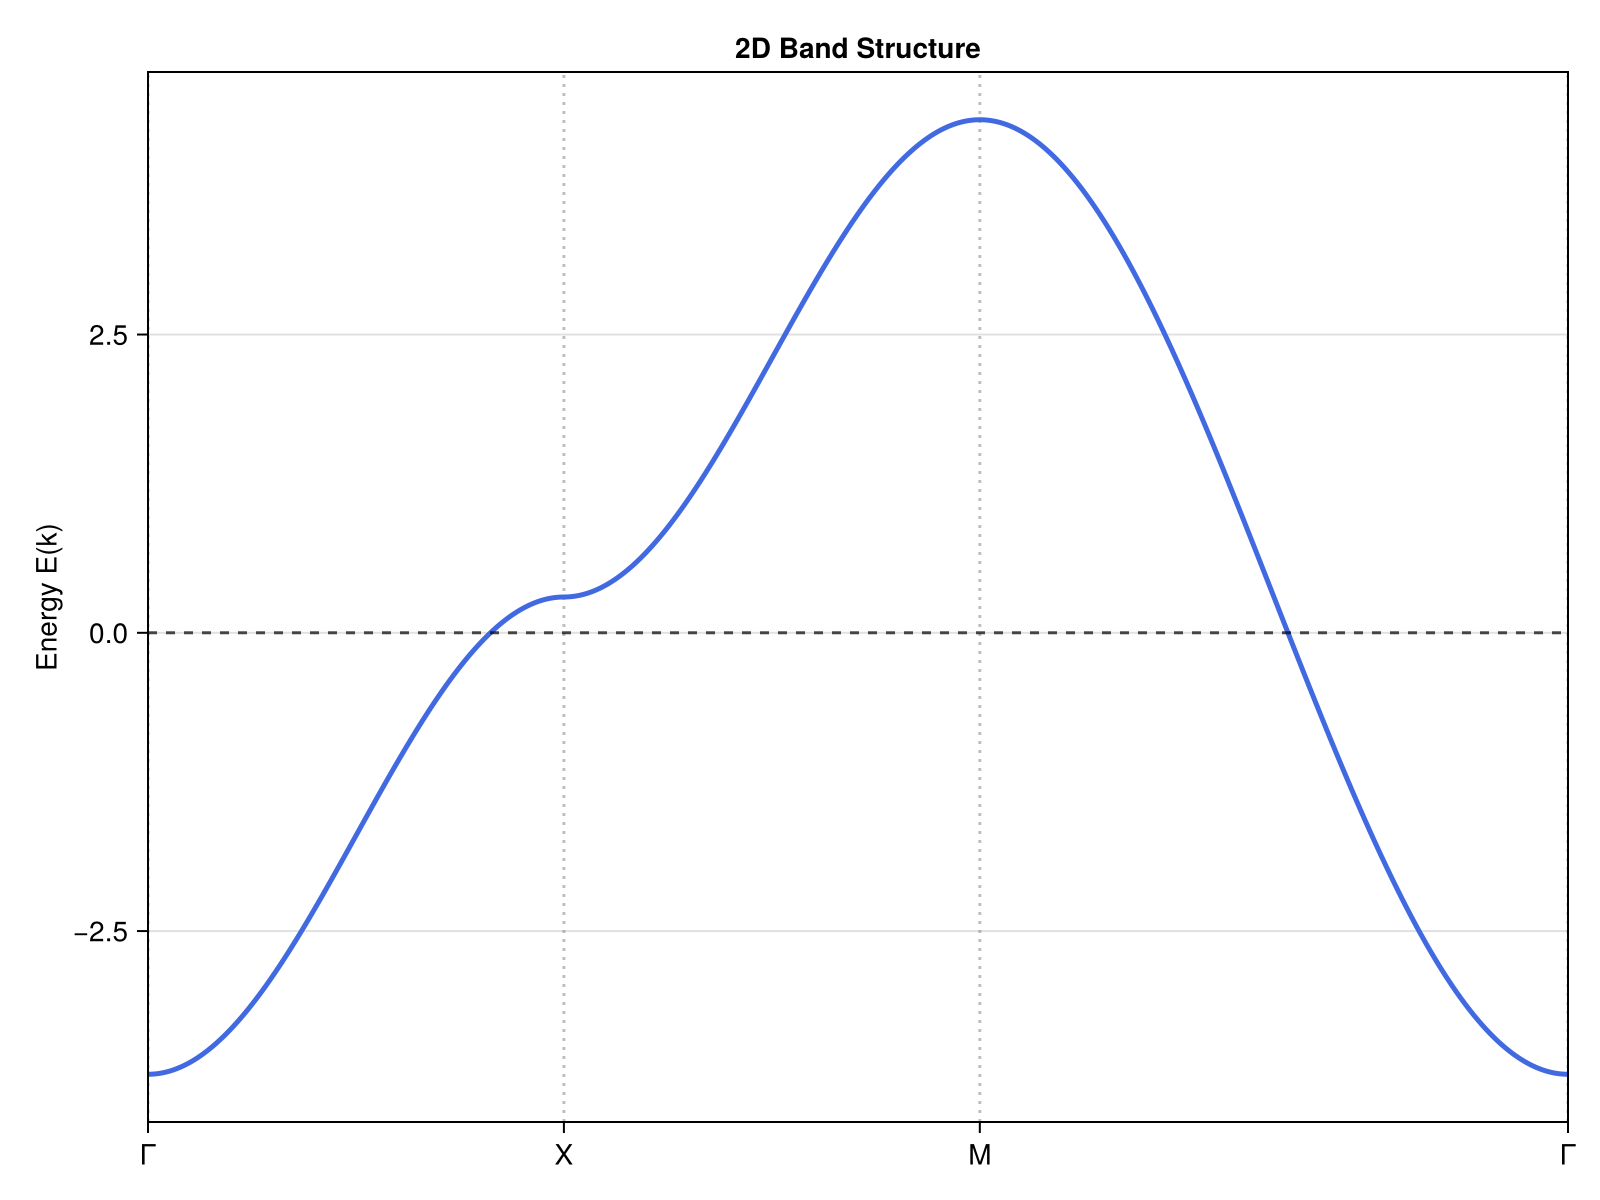

In [10]:
band_data = calculate_bands(model, path)
plot(band_data)


### Coulomb interaction

In [9]:
interaction = BareCoulombInteraction(0.01)

fluctuation = DirectChannel()
phis = range(0.0, 1.0, length=100)
Ts = range(0.1, 0.4, length=6)

omegas = range(0.0, 5.0, length=400)
T_plasmon = 0.01

0.01

In [10]:
band_data = compute_renormalized_band_data(Ts, fluctuation, tb, interaction, kgrid, path)

RenormalizedBandData{2}(KPath{2}(StaticArraysCore.SVector{2, Float64}[[0.0, 0.0], [0.010471975511965976, 0.0], [0.020943951023931952, 0.0], [0.03141592653589793, 0.0], [0.041887902047863905, 0.0], [0.05235987755982988, 0.0], [0.06283185307179585, 0.0], [0.07330382858376185, 0.0], [0.08377580409572781, 0.0], [0.09424777960769379, 0.0]  …  [0.0942477796076937, 0.0942477796076937], [0.08377580409572793, 0.08377580409572793], [0.07330382858376172, 0.07330382858376172], [0.06283185307179595, 0.06283185307179595], [0.05235987755982974, 0.05235987755982974], [0.04188790204786397, 0.04188790204786397], [0.031415926535897754, 0.031415926535897754], [0.020943951023931984, 0.020943951023931984], [0.01047197551196577, 0.01047197551196577], [0.0, 0.0]], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1, 201, 401, 601], ["Γ", "X", "M", "Γ"]), [-2.8; -2.7999013059853284; … ; -2.7998025937072035; -2.8;;], [-2.3; -2.2999013059853284; … ; -2.2998

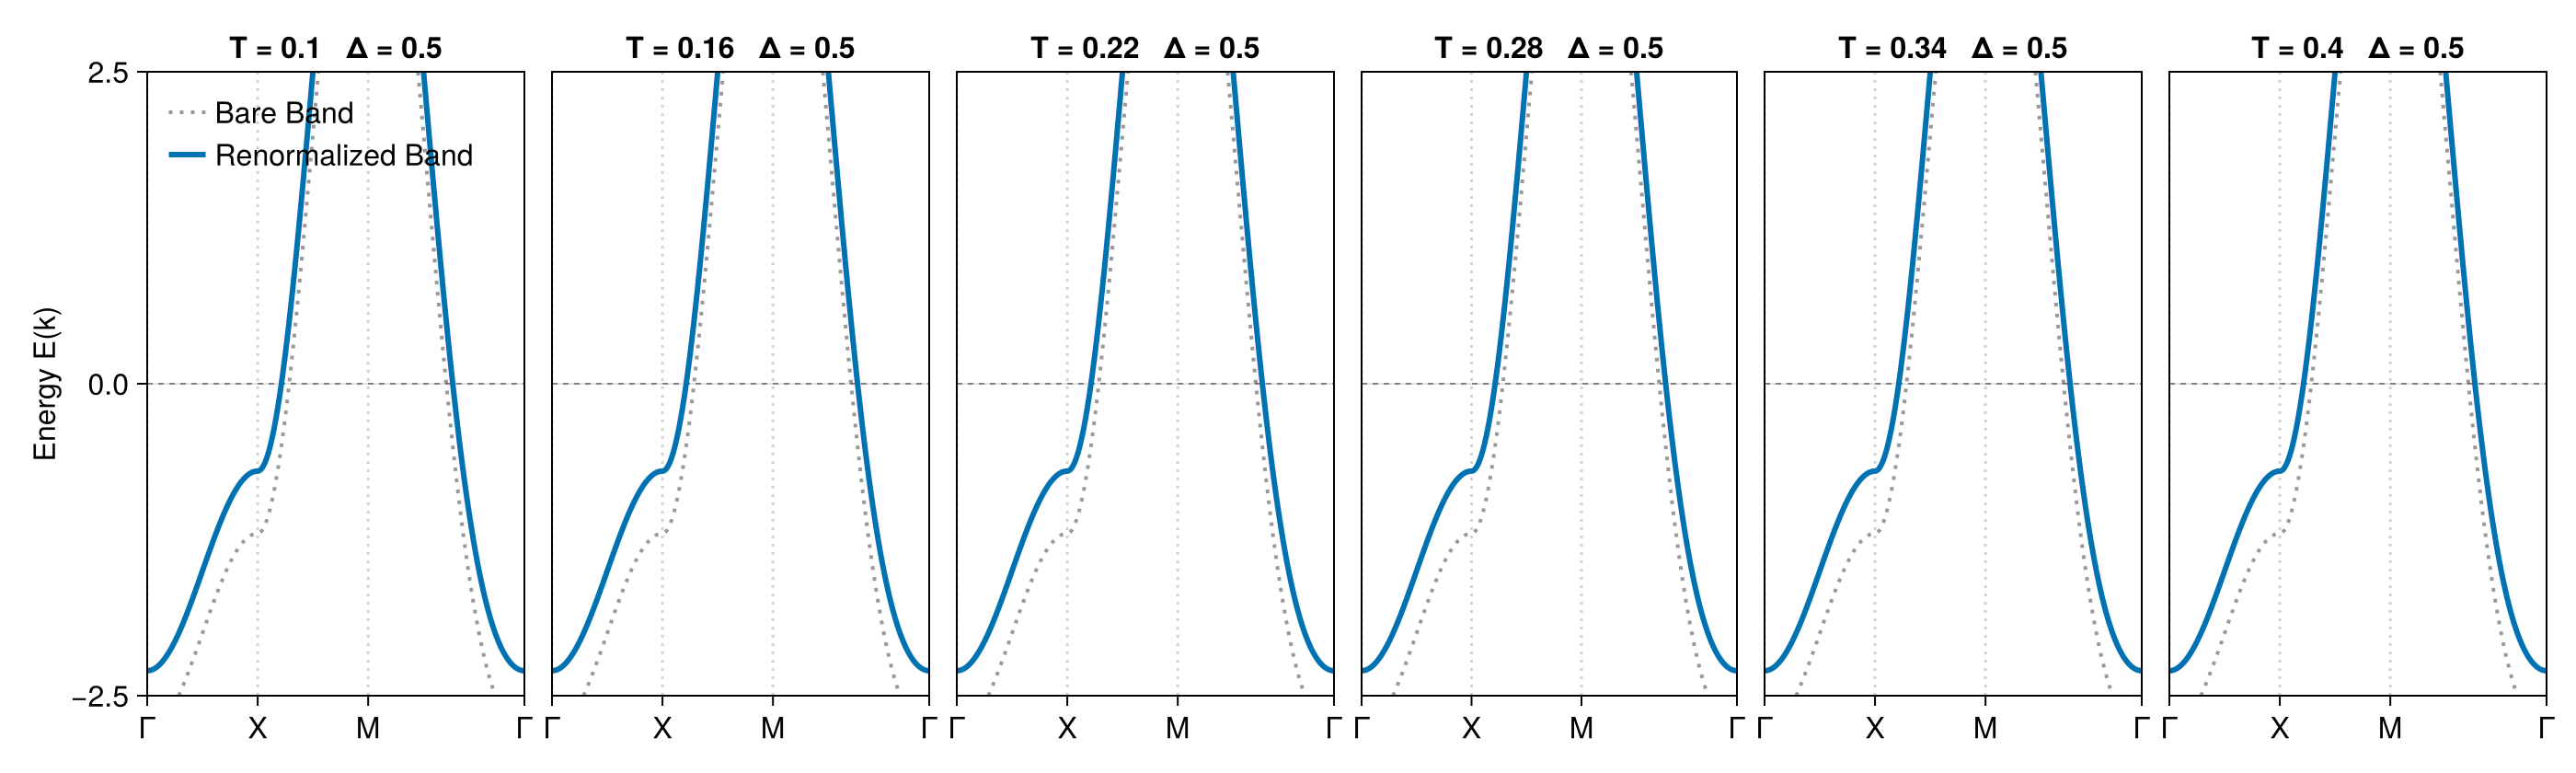

In [11]:
plot(band_data)

In [4]:
# 对当前版本的包，等离激元示例直接展示裸密度响应的动态谱函数。
# 相互作用修正可以在后处理阶段进一步叠加到 χ₀(q, ω) 上。

spectral_matrix = load("/Users/yimingzhang/Developer/theory/Eliashberg/examples/plasmon/out/plasmon_2d_20260417_154548/plasmon_scan.jld2")

SpectralMapData{2}(KPath (2D, 3001 points), [0.0, 0.008008008008008008, 0.016016016016016016, 0.024024024024024024, 0.03203203203203203, 0.04004004004004004, 0.04804804804804805, 0.056056056056056056, 0.06406406406406406, 0.07207207207207207  …  7.927927927927928, 7.935935935935936, 7.943943943943944, 7.951951951951952, 7.95995995995996, 7.967967967967968, 7.975975975975976, 7.983983983983984, 7.991991991991992, 8.0], [0.0 0.0 … 0.0 0.0; -0.0003628142457968077 0.007947862295365727 … -2.215608933059807e-9 -2.2116816765033835e-9; … ; -0.0011921591891852826 0.012267133465097193 … -6.126422162894964e-9 -6.115156096600878e-9; 0.0 0.0 … 0.0 0.0], 0.0, nothing, 0.01)

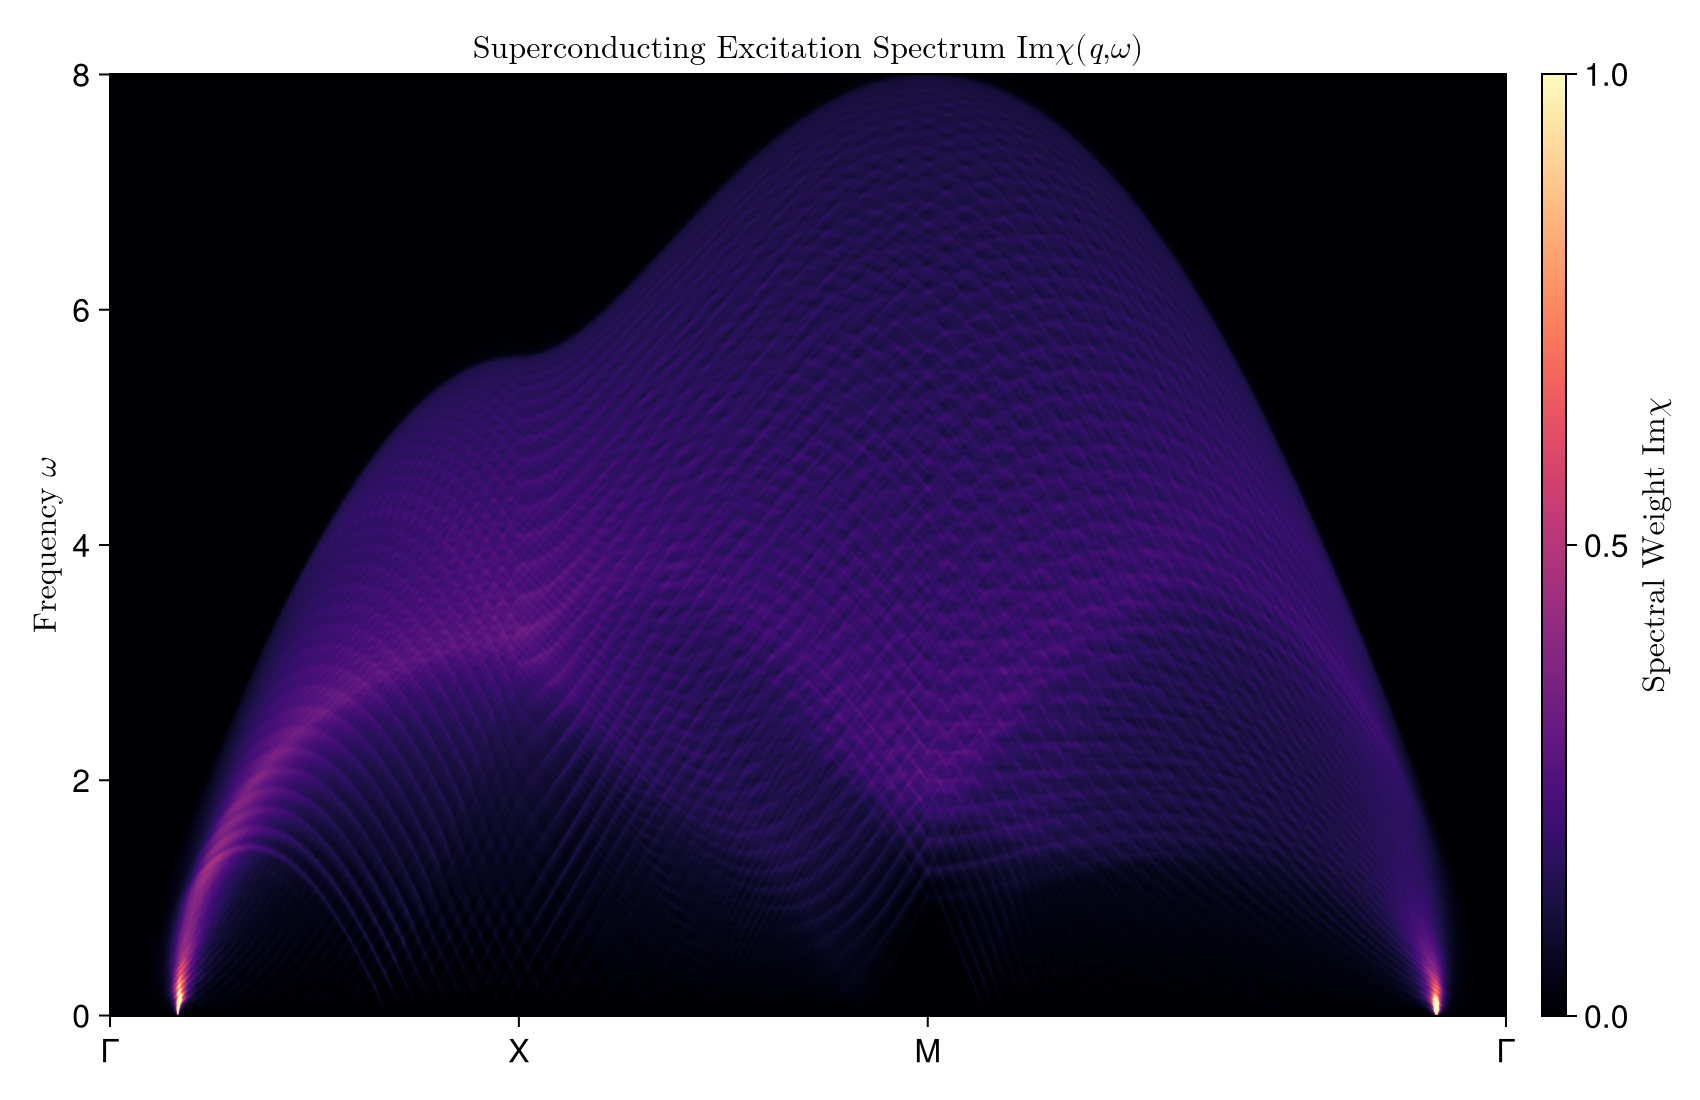

In [5]:
# plot_result_file("/Users/yimingzhang/Developer/theory/Eliashberg/results/plasmon_2d_20260413_112553/plasmon_scan.jld2"; mode=:spectral)
plot(spectral_matrix, colorrange=(0, 1.0))